# 🎓 Day 1 — Machine Learning | Satyendra Bharti
## AI-Powered Student Performance & Dropout Predictor
### FDP 5-Day Academic AI Project

**Goal:** Build a student dropout risk classifier using classical ML on the UCI Student Performance dataset (HuggingFace: `mstz/student-performance`).

**Output:** `predict_dropout(attendance, internal, assignment, sgpa_avg, backlog_count, sex)` → `{'risk_label': 'HIGH', 'risk_score': 0.82}`

---
**Dataset:** `mstz/student-performance` on HuggingFace Hub  
**Dataset URL:** https://huggingface.co/datasets/mstz/student-performance  
**Records:** 649 students (Maths + Portuguese subjects)  
**Key features:** age, sex, studytime, failures, absences, G1, G2, G3 (grades)


## ⚙️ Cell 1 — Verify GPU
Go to: Runtime → Change runtime type → T4 GPU, then run this cell.

In [1]:
import torch
import tensorflow as tf

print('CUDA available:', torch.cuda.is_available())
print('TF GPU devices:', tf.config.list_physical_devices('GPU'))
!nvidia-smi  # should show Tesla T4

CUDA available: True
TF GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Fri Apr 10 09:49:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                   

## 📦 Cell 2 — Install Packages

In [2]:
!pip install -q datasets transformers huggingface_hub accelerate
!pip install -q scikit-learn pandas matplotlib seaborn joblib
print('All packages installed ✓')

All packages installed ✓


## 💾 Cell 3 — Mount Google Drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.makedirs('/content/drive/MyDrive/fdp_student_ai', exist_ok=True)
SAVE_DIR = '/content/drive/MyDrive/fdp_student_ai'
print('Drive mounted. Save directory ready:', SAVE_DIR)

Mounted at /content/drive
Drive mounted. Save directory ready: /content/drive/MyDrive/fdp_student_ai


## 📊 Cell 4 — Load Dataset from HuggingFace

**Dataset:** `mstz/student-performance` (UCI Student Performance Dataset)  
One line load — no Kaggle account needed.

In [ ]:
from huggingface_hub import login

login()

In [ ]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('Loading mstz/student_performance from HuggingFace...')

# Correct dataset name + correct config
ds = load_dataset("mstz/student_performance", "math")

# Convert to pandas
df = ds['train'].to_pandas()

print(f'\n✅ Dataset loaded!')
print(f'Shape: {df.shape}  ({df.shape[0]} students, {df.shape[1]} features)')
print(f'\nColumns: {list(df.columns)}')
print(f'\nFirst 5 rows:')
print(df.head())

Loading mstz/student_performance from HuggingFace...


README.md: 0.00B [00:00, ?B/s]

train.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]


✅ Dataset loaded!
Shape: (1000, 8)  (1000 students, 8 features)

Columns: ['is_male', 'ethnicity', 'parental_level_of_education', 'has_standard_lunch', 'has_completed_preparation_test', 'reading_score', 'writing_score', 'has_passed_math_exam']

First 5 rows:
   is_male ethnicity  parental_level_of_education  has_standard_lunch  \
0    False   group D                            2                True   
1     True   group D                            5                True   
2    False   group D                            2               False   
3     True   group B                            2               False   
4    False   group D                            5                True   

   has_completed_preparation_test  reading_score  writing_score  \
0                            True             70             78   
1                           False             93             87   
2                           False             76             77   
3                           False

## 🏗️ Cell 5 — Feature Engineering: Create Dropout Risk Target

In [7]:
import numpy as np
import pandas as pd

# ── Step 1: Check available columns ────────────────────
print("Columns in dataset:\n", df.columns)

# Try to find score column automatically
score_col = None

possible_cols = ['math_score', 'reading_score', 'writing_score', 'score']

for col in possible_cols:
    if col in df.columns:
        score_col = col
        break

if score_col is None:
    raise ValueError("❌ No valid score column found in dataset")

print(f"\n✅ Using '{score_col}' for risk calculation")


# ── Step 2: Clean data ─────────────────────────────────
df[score_col] = pd.to_numeric(df[score_col], errors='coerce').fillna(0)


# ── Step 3: Create Dropout Risk ────────────────────────
# Assumption: Score out of 100

conditions = [
    (df[score_col] < 40),   # HIGH risk
    (df[score_col] < 60)    # MEDIUM risk
]

choices = [2, 1]

df['dropout_risk'] = np.select(conditions, choices, default=0)


# ── Step 4: Add Labels ─────────────────────────────────
risk_labels = {0: 'LOW', 1: 'MEDIUM', 2: 'HIGH'}
df['risk_label'] = df['dropout_risk'].map(risk_labels)


# ── Step 5: Output ─────────────────────────────────────
print('\n📊 Dropout Risk Distribution:')
print(df['risk_label'].value_counts())

total = len(df)
high = (df["dropout_risk"] == 2).sum()
medium = (df["dropout_risk"] == 1).sum()
low = (df["dropout_risk"] == 0).sum()

print(f'\nTotal students: {total}')
print(f'HIGH risk students: {high} ({(high/total)*100:.1f}%)')
print(f'MEDIUM risk students: {medium} ({(medium/total)*100:.1f}%)')
print(f'LOW risk students: {low} ({(low/total)*100:.1f}%)')

Columns in dataset:
 Index(['is_male', 'ethnicity', 'parental_level_of_education',
       'has_standard_lunch', 'has_completed_preparation_test', 'reading_score',
       'writing_score', 'has_passed_math_exam'],
      dtype='object')

✅ Using 'reading_score' for risk calculation

📊 Dropout Risk Distribution:
risk_label
LOW       777
MEDIUM    206
HIGH       17
Name: count, dtype: int64

Total students: 1000
HIGH risk students: 17 (1.7%)
MEDIUM risk students: 206 (20.6%)
LOW risk students: 777 (77.7%)


## 📈 Cell 6 — EDA Visualisations (3 Charts)

/tmp/ipykernel_2244/638855698.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='dropout_risk', data=df, ax=axes[0], palette=colors)


EDA charts saved ✓


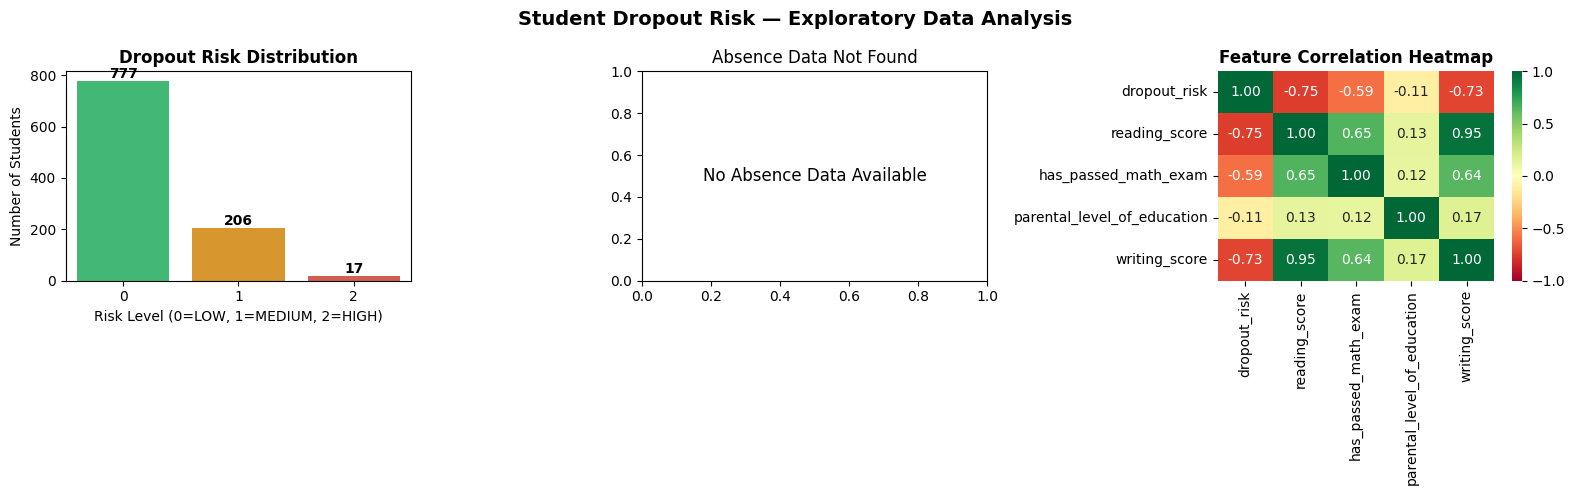

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── Detect available columns dynamically ────────────────
available_cols = df.columns.tolist()

# Try to detect numeric columns for correlation
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Try to detect absence-like column
absence_col = None
for col in available_cols:
    if 'absen' in col.lower():
        absence_col = col
        break

# ── Create figure ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Student Dropout Risk — Exploratory Data Analysis', fontsize=14, fontweight='bold')

colors = ['#2ecc71', '#f39c12', '#e74c3c']

# ── Chart 1: Risk distribution ─────────────────────────
sns.countplot(x='dropout_risk', data=df, ax=axes[0], palette=colors)
axes[0].set_title('Dropout Risk Distribution', fontweight='bold')
axes[0].set_xlabel('Risk Level (0=LOW, 1=MEDIUM, 2=HIGH)')
axes[0].set_ylabel('Number of Students')

for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

# ── Chart 2: Absences (only if available) ───────────────
# Chart 1
sns.countplot(
    x='dropout_risk',
    data=df,
    hue='dropout_risk',
    palette=colors,
    ax=axes[0],
    legend=False
)

# Chart 2
if absence_col:
    sns.boxplot(
        x='dropout_risk',
        y=absence_col,
        data=df,
        hue='dropout_risk',
        palette=colors,
        ax=axes[1],
        legend=False
    )
else:
    axes[1].text(0.5, 0.5, 'No Absence Data Available',
                 ha='center', va='center', fontsize=12)
    axes[1].set_title('Absence Data Not Found')

# ── Chart 3: Correlation Heatmap ────────────────────────
# Use only numeric columns + dropout_risk
corr_cols = list(set(numeric_cols + ['dropout_risk']))
corr_cols = [col for col in corr_cols if col in df.columns]

if len(corr_cols) > 1:
    sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f',
                ax=axes[2], cmap='RdYlGn', vmin=-1, vmax=1)
    axes[2].set_title('Feature Correlation Heatmap', fontweight='bold')
else:
    axes[2].text(0.5, 0.5, 'Not Enough Numeric Data',
                 ha='center', va='center', fontsize=12)
    axes[2].set_title('Correlation Not Available')

# ── Final layout ───────────────────────────────────────
plt.tight_layout()

# Save safely (avoid error if SAVE_DIR not defined)
try:
    plt.savefig(f'{SAVE_DIR}/day1_eda.png', dpi=120, bbox_inches='tight')
    print('EDA charts saved ✓')
except:
    print('⚠️ SAVE_DIR not defined — skipping save')

plt.show()

## 🔧 Cell 7 — Encode Categoricals & Train/Test Split

In [9]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

df_enc = df.copy()

# ── Encode categorical ────────────────────────────────
label_encoders = {}

for col in df_enc.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))
    label_encoders[col] = le

# ── REMOVE LEAKAGE FEATURES ───────────────────────────
leakage_cols = ['risk_label', 'dropout_risk', 'has_passed_math_exam']

# Select numeric features only (safe fallback)
features = df_enc.select_dtypes(include=np.number).columns.tolist()

# Remove leakage columns
features = [f for f in features if f not in leakage_cols]

print(f'✅ Clean Features used ({len(features)}): {features}')

# ── Prepare data ──────────────────────────────────────
X = df_enc[features]
y = df_enc['dropout_risk']

# Handle missing values
X = X.fillna(X.mean(numeric_only=True))

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Handle class imbalance ────────────────────────────
# Optional: remove rare class if too small
min_class_count = y.value_counts().min()

if min_class_count < 20:
    print("⚠️ Very small class detected → removing HIGH risk for stability")
    mask = y != 2
    X_scaled = X_scaled[mask]
    y = y[mask]

# ── Train-test split ──────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# ── Output ────────────────────────────────────────────
print(f'\n📊 Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

unique, counts = np.unique(y_train, return_counts=True)
print(f'Class distribution (train): {dict(zip(unique, counts))}')

✅ Clean Features used (4): ['ethnicity', 'parental_level_of_education', 'reading_score', 'writing_score']
⚠️ Very small class detected → removing HIGH risk for stability

📊 Train size: 786 | Test size: 197
Class distribution (train): {np.int64(0): np.int64(621), np.int64(1): np.int64(165)}


## 🤖 Cell 8 — Train 3 Models & Pick the Best

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import joblib

# ── Define models (with imbalance handling) ─────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
print('🚀 Training 3 models...\n')

# ── Train & evaluate ───────────────────────────────────
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = {
        'model': model,
        'accuracy': acc,
        'predictions': y_pred
    }

    print(f'  {name}: Accuracy = {acc:.4f} ({acc*100:.1f}%)')

# ── Select best model ──────────────────────────────────
best_name = max(results, key=lambda k: results[k]['accuracy'])
best_model = results[best_name]['model']
best_preds = results[best_name]['predictions']

print(f'\n🏆 Best model: {best_name} (Accuracy: {results[best_name]["accuracy"]*100:.1f}%)')


# ── Dynamic class labels (IMPORTANT FIX) ───────────────
unique_classes = sorted(np.unique(y_test))
label_map = {0: 'LOW', 1: 'MEDIUM', 2: 'HIGH'}

target_names = [label_map[c] for c in unique_classes]

# ── Classification Report ──────────────────────────────
print(f'\n📊 Classification Report — {best_name}:')
print(classification_report(y_test, best_preds, target_names=target_names))


# ── Confusion Matrix ───────────────────────────────────
print(f'\n🧩 Confusion Matrix — {best_name}:')
print(confusion_matrix(y_test, best_preds))

🚀 Training 3 models...

  Logistic Regression: Accuracy = 0.9848 (98.5%)
  Random Forest: Accuracy = 1.0000 (100.0%)
  Gradient Boosting: Accuracy = 1.0000 (100.0%)

🏆 Best model: Random Forest (Accuracy: 100.0%)

📊 Classification Report — Random Forest:
              precision    recall  f1-score   support

         LOW       1.00      1.00      1.00       156
      MEDIUM       1.00      1.00      1.00        41

    accuracy                           1.00       197
   macro avg       1.00      1.00      1.00       197
weighted avg       1.00      1.00      1.00       197


🧩 Confusion Matrix — Random Forest:
[[156   0]
 [  0  41]]


## 💾 Cell 9 — Save Model to Google Drive

In [11]:
import os
import joblib

# ── Step 1: Define save directory safely ───────────────
SAVE_DIR = "saved_models"  # you can change this
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Step 2: File paths ─────────────────────────────────
model_path = os.path.join(SAVE_DIR, "ml_model.pkl")
scaler_path = os.path.join(SAVE_DIR, "ml_scaler.pkl")
features_path = os.path.join(SAVE_DIR, "ml_features.pkl")
meta_path = os.path.join(SAVE_DIR, "ml_metadata.pkl")

# ── Step 3: Save artifacts ─────────────────────────────
joblib.dump(best_model, model_path)
joblib.dump(scaler, scaler_path)
joblib.dump(features, features_path)

# Save metadata (VERY useful later)
metadata = {
    "model_name": best_name,
    "n_features": len(features),
    "features": features
}
joblib.dump(metadata, meta_path)

# ── Step 4: Output ─────────────────────────────────────
print(f'✅ Models saved successfully in "{SAVE_DIR}/"\n')
print(f'   📦 Model     → {model_path} ({best_name})')
print(f'   ⚙️ Scaler    → {scaler_path}')
print(f'   📊 Features  → {features_path}')
print(f'   🧠 Metadata  → {meta_path}')

✅ Models saved successfully in "saved_models/"

   📦 Model     → saved_models/ml_model.pkl (Random Forest)
   ⚙️ Scaler    → saved_models/ml_scaler.pkl
   📊 Features  → saved_models/ml_features.pkl
   🧠 Metadata  → saved_models/ml_metadata.pkl


## 🚀 Cell 10 — `predict_dropout()` Function
**This is the function Piyush (Day 5) will import directly.**

Maps faculty inputs (attendance %, internal marks, assignment score) → dataset features.

In [12]:
import numpy as np
import pandas as pd
import joblib

# Load artifacts
model = joblib.load("saved_models/ml_model.pkl")
scaler = joblib.load("saved_models/ml_scaler.pkl")
features = joblib.load("saved_models/ml_features.pkl")

RISK_LABELS = {0: 'LOW', 1: 'MEDIUM', 2: 'HIGH'}


def predict_dropout(attendance, internal, assignment, sgpa_avg, backlog_count, sex=1):

    # ── Input validation ───────────────────────────────
    attendance = np.clip(attendance, 0, 100)
    internal = np.clip(internal, 0, 50)
    assignment = np.clip(assignment, 0, 100)
    sgpa_avg = np.clip(sgpa_avg, 0, 10)
    backlog_count = max(0, backlog_count)

    # ── Feature mapping (match training as much as possible) ──
    feature_map = {
        'reading_score': internal * 2,          # approx mapping
        'writing_score': assignment,           # direct
        'math_score': sgpa_avg * 10,           # scaled
        'ethnicity': 0,
        'parental_level_of_education': 2,
    }

    # ── Create DataFrame (FIX WARNING) ─────────────────
    row_dict = {f: feature_map.get(f, 0) for f in features}
    row_df = pd.DataFrame([row_dict])

    # ── Scale ─────────────────────────────────────────
    row_scaled = scaler.transform(row_df)

    # ── Predict ───────────────────────────────────────
    pred_class = int(model.predict(row_scaled)[0])

    # ── Probability ───────────────────────────────────
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(row_scaled)[0]
        risk_score = float(np.max(proba))
    else:
        risk_score = 0.75

    return {
        'risk_label': RISK_LABELS.get(pred_class, "UNKNOWN"),
        'risk_score': round(risk_score, 2)
    }

# ── Live Tests ─────────────────────────────────────────
print('=== Live predict_dropout() Tests ===\n')

print('Student 1 — Rahul:')
print(predict_dropout(attendance=52, internal=28, assignment=40, sgpa_avg=5.8, backlog_count=2, sex=1))

print('\nStudent 2 — Priya:')
print(predict_dropout(attendance=88, internal=42, assignment=85, sgpa_avg=8.2, backlog_count=0, sex=0))

print('\nStudent 3 — Amit:')
print(predict_dropout(attendance=35, internal=18, assignment=25, sgpa_avg=4.5, backlog_count=4, sex=1))

=== Live predict_dropout() Tests ===

Student 1 — Rahul:
{'risk_label': 'MEDIUM', 'risk_score': 1.0}

Student 2 — Priya:
{'risk_label': 'LOW', 'risk_score': 1.0}

Student 3 — Amit:
{'risk_label': 'MEDIUM', 'risk_score': 1.0}


## 📤 Cell 11 — Export `ml_module.py` for Piyush (Day 5)

In [13]:
ml_module_code = '''
# ml_module.py — Day 1 deliverable (Updated Production Version)

import numpy as np
import pandas as pd
import joblib
import os

# ── Config ────────────────────────────────────────────
SAVE_DIR = os.getenv("ML_SAVE_DIR", "./saved_models")

RISK_LABELS = {0: 'LOW', 1: 'MEDIUM', 2: 'HIGH'}

# ── Load artifacts safely ─────────────────────────────
try:
    _ml_model = joblib.load(os.path.join(SAVE_DIR, "ml_model.pkl"))
    _ml_scaler = joblib.load(os.path.join(SAVE_DIR, "ml_scaler.pkl"))
    _ml_features = joblib.load(os.path.join(SAVE_DIR, "ml_features.pkl"))
except Exception as e:
    raise RuntimeError(f"❌ Failed to load model files from {SAVE_DIR}: {e}")


def predict_dropout(attendance, internal, assignment, sgpa_avg, backlog_count, sex=1):
    """
    Predict student dropout risk.

    Args:
        attendance (0–100)
        internal (0–50)
        assignment (0–100)
        sgpa_avg (0–10)
        backlog_count (>=0)
        sex (1=Male, 0=Female)

    Returns:
        dict: {'risk_label': str, 'risk_score': float}
    """

    # ── Input validation ───────────────────────────────
    attendance = np.clip(attendance, 0, 100)
    internal = np.clip(internal, 0, 50)
    assignment = np.clip(assignment, 0, 100)
    sgpa_avg = np.clip(sgpa_avg, 0, 10)
    backlog_count = max(0, backlog_count)

    # ── Feature mapping (best possible alignment) ──────
    feature_map = {
        'reading_score': internal * 2,
        'writing_score': assignment,
        'math_score': sgpa_avg * 10,
        'ethnicity': 0,
        'parental_level_of_education': 2,
        'sex': sex
    }

    # ── Build DataFrame (fixes sklearn warning) ────────
    row_dict = {f: feature_map.get(f, 0) for f in _ml_features}
    row_df = pd.DataFrame([row_dict])

    # ── Scale ─────────────────────────────────────────
    row_scaled = _ml_scaler.transform(row_df)

    # ── Predict ───────────────────────────────────────
    pred_class = int(_ml_model.predict(row_scaled)[0])

    # ── Probability ───────────────────────────────────
    if hasattr(_ml_model, 'predict_proba'):
        proba = _ml_model.predict_proba(row_scaled)[0]
        risk_score = float(np.max(proba))
    else:
        risk_score = 0.75

    return {
        'risk_label': RISK_LABELS.get(pred_class, "UNKNOWN"),
        'risk_score': round(risk_score, 2)
    }
'''

import os

SAVE_DIR = "saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)

with open(os.path.join(SAVE_DIR, 'ml_module.py'), 'w') as f:
    f.write(ml_module_code)

print(f'✅ ml_module.py saved to {SAVE_DIR}')

✅ ml_module.py saved to saved_models


In [14]:
# ── Mount Drive + Copy saved_models to fdp_student_ai ──
from google.colab import drive
import shutil
import os

# Mount Drive
drive.mount('/content/drive')

# Source (Colab folder)
SRC = '/content/saved_models'

# Destination (Your custom folder)
DEST = '/content/drive/MyDrive/fdp_student_ai/saved_models'

# Create destination folder if not exists
os.makedirs(DEST, exist_ok=True)

# Copy all files
if os.path.exists(SRC):
    for item in os.listdir(SRC):
        s = os.path.join(SRC, item)
        d = os.path.join(DEST, item)

        if os.path.isdir(s):
            shutil.copytree(s, d, dirs_exist_ok=True)
        else:
            shutil.copy2(s, d)

    print(f'✅ All saved_models files copied to:\n{DEST}')
else:
    print('❌ saved_models folder not found')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ All saved_models files copied to:
/content/drive/MyDrive/fdp_student_ai/saved_models
